# Listings data preparation 
In this notebook we prepare Airbnb listings dataset for predictive modeling. We aim to identify the variables that may explain listing prices in Rome and clean the dataset. 
Our target variable selected for this stage is the lsiting nightly price.

In [1]:
#setup
from sklearn.cluster import KMeans, DBSCAN
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from pathlib import Path
import pandas as pd
import numpy as np
from geopy.distance import geodesic as gp
import seaborn as sns


PROJECT_ROOT = Path.cwd().parent

print("Project root:", PROJECT_ROOT)

Project root: /Users/juandavid/Desktop/data/airbnb-rome-analysis


## 1. Load dataset

In [2]:
listings = pd.read_csv(
    PROJECT_ROOT / "data" / "listings.csv"
)
listings.head()

,id,listing_url,scrape_id,last_scraped,source,name,description,neighborhood_overview,picture_url,host_id,...,review_scores_communication,review_scores_location,review_scores_value,license,instant_bookable,calculated_host_listings_count,calculated_host_listings_count_entire_homes,calculated_host_listings_count_private_rooms,calculated_host_listings_count_shared_rooms,reviews_per_month
0,2737,https://www.airbnb.com/rooms/2737,20260620165006,2026-06-20,city scrape,"Elif's room in cozy, clean flat.",10 min by bus you can get to Piazza Venezia or...,NaN,https://a0.muscache.com/pictures/41225252/e955...,3047,...,5.00,4.40,4.40,NaN,NaN,6,0,6,0,0.04
1,11834,https://www.airbnb.com/rooms/11834,20260620165006,2026-06-22,city scrape,"Charming Boschetto Studio, Rome",Fantastic apartment in the Monti district. The...,NaN,https://a0.muscache.com/pictures/miso/Hosting-...,44552,...,4.96,4.99,4.82,IT058091C29VJSIZQZ,NaN,1,1,0,0,1.64
2,12398,https://www.airbnb.com/rooms/12398,20260620165006,2026-06-23,city scrape,Casa Donatello - Home far from Home,Casa Donatello is a newly renovated two-bedroo...,NaN,https://a0.muscache.com/pictures/miso/Hosting-...,11756,...,5.00,4.89,4.83,it058091c2kv6epw8f,NaN,1,1,0,0,0.45
3,19965,https://www.airbnb.com/rooms/19965,20260620165006,2026-06-22,city scrape,S. Peter's Square 5 Min WALK cozy quite 2 bdr,Lovely 2 bedrooms apartment AT ONLY 5 MINUTES ...,NaN,https://a0.muscache.com/pictures/hosting/Hosti...,75450,...,4.90,4.91,4.56,IT058091C20YD35BX2,NaN,1,1,0,0,1.11
4,20534,https://www.airbnb.com/rooms/20534,20260620165006,2026-06-21,city scrape,DormiRoma - Cedro 1 Apartment - Trastevere,Cedro 1 Apartment is located in a beautiful s...,NaN,https://a0.muscache.com/pictures/miso/Hosting-...,77540,...,4.79,4.92,4.27,IT058091B4I3RFDVLG,NaN,5,5,0,0,0.26


## 2. Exploration

In [3]:
listings.shape

(37084, 90)

In [4]:
listings.info()

<class 'pandas.DataFrame'>
RangeIndex: 37084 entries, 0 to 37083
Data columns (total 90 columns):
 #   Column                                        Non-Null Count  Dtype  
---  ------                                        --------------  -----  
 0   id                                            37084 non-null  int64  
 1   listing_url                                   37084 non-null  str    
 2   scrape_id                                     37084 non-null  int64  
 3   last_scraped                                  37084 non-null  str    
 4   source                                        37084 non-null  str    
 5   name                                          37084 non-null  str    
 6   description                                   36124 non-null  str    
 7   neighborhood_overview                         0 non-null      float64
 8   picture_url                                   37084 non-null  str    
 9   host_id                                       37084 non-null  int64  
 1

In [5]:
listings.columns.tolist()

['id',
 'listing_url',
 'scrape_id',
 'last_scraped',
 'source',
 'name',
 'description',
 'neighborhood_overview',
 'picture_url',
 'host_id',
 'host_url',
 'host_profile_id',
 'host_profile_url',
 'host_name',
 'host_since',
 'hosts_time_as_user_years',
 'hosts_time_as_user_months',
 'hosts_time_as_host_years',
 'hosts_time_as_host_months',
 'host_location',
 'host_about',
 'host_response_time',
 'host_response_rate',
 'host_acceptance_rate',
 'host_is_superhost',
 'host_thumbnail_url',
 'host_picture_url',
 'host_neighbourhood',
 'host_listings_count',
 'host_total_listings_count',
 'host_verifications',
 'host_has_profile_pic',
 'host_identity_verified',
 'neighbourhood',
 'neighbourhood_cleansed',
 'neighbourhood_group_cleansed',
 'latitude',
 'longitude',
 'property_type',
 'room_type',
 'accommodates',
 'bathrooms',
 'bathrooms_text',
 'bedrooms',
 'beds',
 'amenities',
 'price',
 'price_quote_checkin_date',
 'price_quote_checkout_date',
 'price_quote_total_price',
 'price_quote

## 4. Dataset cleaning
In the dataset the `price` variable is stored as text and contains currency symbols.
To use it in our model, it must be converted into a numeric format. 

In [6]:
listings["price"].head()

0     $59.52
1        NaN
2    $117.13
3    $160.60
4    $243.67
Name: price, dtype: str

In [7]:
listings["price"].isna().sum()

np.int64(2760)

In [8]:
listings["price"] = (
    listings["price"]
    .str.replace("$", "", regex=False)
    .str.replace(",", "", regex=False)
    .astype(float)
)

In [9]:
# to verify
listings["price"].head()

0     59.52
1       NaN
2    117.13
3    160.60
4    243.67
Name: price, dtype: float64

Feature selection was guided by the adquire knowledge from Airbnb official webpage about marketplace, prioritazing location variables, accomodation characteristic, host reputation, and guest satisfaction. 
 ## 5. Selection of features
 Having in consideration the complete list of features, we decided to delete the following ones: 
 #### 5.1. Identifiers
 these variables identify the records but they do not contain  information that explains the prices of each residency. Including them would just add noise to the model. 
 #### 5.2. Textual description 
 This group of variables might contain useful information but we need NLP for their analysis. Therefore, we will also exclude them. 
 #### 5.3. Image and media
 Again, is not numerical useful information, it goes beyond our lecture. 
 #### 5.4. Administrative fields
 Variables that describe how the information was retrieved does not affect the listing price.
 #### 5.5. Redundant variables
In this group there are variable that have very similar information between them, if we were to include them we would only create redundance in our models. 
#### 5.6. Reviews
For the first part of our work we will exclude them, but they might be more useful when we apply feature engineering. 

In [10]:
candidate_features = [
    "price",
    "neighbourhood_cleansed",
    "latitude",
    "longitude",
    "property_type",
    "room_type",
    "accommodates",
    "bedrooms",
    "beds",
    "bathrooms",
    "estimated_occupancy_l365d",
    "availability_365",
    "host_is_superhost",
    "host_response_rate",
    "host_acceptance_rate",
    "review_scores_rating",
    "review_scores_cleanliness",
    "review_scores_location",
    "review_scores_value",
    "number_of_reviews",
    "reviews_per_month",
    "minimum_nights",
    "maximum_nights",
    "instant_bookable",
    "amenities",    
    "first_review",      
    "last_review",  
    "last_scraped"
]

# Candidate Features Data Dictionary

| Field | Type | Description |
|---|---|---|
| `price` | currency | Daily price in local currency. Note: the `$` sign is a technical artifact of the export and should be ignored. |
| `neighbourhood_cleansed` | text | The neighbourhood as geocoded using the listing's latitude and longitude against neighborhoods defined by open/public digital shapefiles. |
| `latitude` | numeric | Latitude of the listing, using the WGS84 projection. |
| `longitude` | numeric | Longitude of the listing, using the WGS84 projection. |
| `property_type` | text | Self-selected property type, as entered by the host (e.g. Hotels and Bed and Breakfasts are described as such by their hosts). |
| `room_type` | text | One of `Entire home/apt`, `Private room`, `Shared room`, or `Hotel`. Indicates how much of the space the guest has exclusive access to. |
| `accommodates` | integer | The maximum guest capacity of the listing. |
| `bedrooms` | integer | The number of bedrooms in the listing. |
| `beds` | integer | The number of beds in the listing. |
| `bathrooms` | numeric | The number of bathrooms in the listing. |
| `host_is_superhost` | boolean | `t` = true, `f` = false. Whether the host holds Superhost status. |
| `host_response_rate` | percentage | The rate at which the host responds to new messages/inquiries. |
| `host_acceptance_rate` | percentage | The rate at which the host accepts booking requests. |
| `review_scores_rating` | numeric | The overall review rating score for the listing, as given by past guests. |
| `review_scores_cleanliness` | numeric | The review sub-score for cleanliness, as given by past guests. |
| `review_scores_location` | numeric | The review sub-score for location, as given by past guests. |
| `review_scores_value` | numeric | The review sub-score for value, as given by past guests. |
| `number_of_reviews` | integer | The total number of reviews the listing has received. |
| `reviews_per_month` | numeric | The average number of reviews per month over the lifetime of the listing (calculated field). |
| `minimum_nights` | integer | Minimum number of nights required for a stay (calendar-specific rules may override this). |
| `maximum_nights` | integer | Maximum number of nights allowed for a stay (calendar-specific rules may override this). |
| `instant_bookable` | boolean | `t` = true, `f` = false. Whether a guest can book the listing automatically, without the host needing to approve the request — often an indicator of a commercial listing. |

In [11]:
selected = listings[candidate_features]

selected.head()

,price,neighbourhood_cleansed,latitude,longitude,property_type,room_type,accommodates,bedrooms,beds,bathrooms,...,review_scores_value,number_of_reviews,reviews_per_month,minimum_nights,maximum_nights,instant_bookable,amenities,first_review,last_review,last_scraped
0,59.52,VIII Appia Antica,41.871360,12.482150,Private room,Private room,1,NaN,1.0,1.5,...,4.40,5,0.04,31.0,1125.0,NaN,"[""Free parking on premises"", ""High chair"", ""Pa...",2014-12-26,2015-05-08,2026-06-20
1,NaN,I Centro Storico,41.895447,12.491181,Entire rental unit,Entire home/apt,2,1.0,1.0,1.0,...,4.82,302,1.64,2.0,28.0,NaN,"[""Shower gel"", ""Baking sheet"", ""Dishes and sil...",2011-05-01,2026-06-07,2026-06-22
2,117.13,II Parioli/Nomentano,41.925820,12.469280,Entire rental unit,Entire home/apt,3,2.0,3.0,1.0,...,4.83,85,0.45,31.0,365.0,NaN,"[""Exterior security cameras on property"", ""Fre...",2010-10-18,2025-08-01,2026-06-23
3,160.60,I Centro Storico,41.908230,12.452930,Entire condo,Entire home/apt,5,2.0,3.0,1.0,...,4.56,195,1.11,2.0,1125.0,NaN,"[""Shower gel"", ""Free washer \u2013 In unit"", ""...",2012-01-10,2026-06-13,2026-06-22
4,243.67,I Centro Storico,41.889920,12.468230,Entire vacation home,Entire home/apt,4,1.0,3.0,1.0,...,4.27,50,0.26,3.0,365.0,NaN,"[""Shampoo"", ""Shower gel"", ""Fire extinguisher"",...",2010-08-21,2022-11-22,2026-06-21


In [12]:
selected = selected.dropna(subset=["price"])

## 6. Missing values analysis
This is an important step to comprehend the information that our model carries and therefore after being able to realise a proper selection of variables. 

In [13]:
missing_table = pd.DataFrame({
    "missing_count": selected.isna().sum(),
    "missing_pct": selected.isna().mean() * 100
})

missing_table = (
    missing_table
    .sort_values("missing_pct", ascending=False)
)

missing_table

,missing_count,missing_pct
host_acceptance_rate,34324,100.000000
host_response_rate,34324,100.000000
instant_bookable,34324,100.000000
bedrooms,6104,17.783475
last_review,3750,10.925300
first_review,3750,10.925300
reviews_per_month,3750,10.925300
review_scores_value,3748,10.919473
review_scores_location,3748,10.919473
review_scores_cleanliness,3747,10.916560


In [14]:
missing_table[missing_table["missing_count"] > 0]

,missing_count,missing_pct
host_acceptance_rate,34324,100.000000
host_response_rate,34324,100.000000
instant_bookable,34324,100.000000
bedrooms,6104,17.783475
last_review,3750,10.925300
first_review,3750,10.925300
reviews_per_month,3750,10.925300
review_scores_value,3748,10.919473
review_scores_location,3748,10.919473
review_scores_cleanliness,3747,10.916560


## 7. Correction of percentage variables
`host_response_rate`
`host_acceptance_rate`
are stored as percentages and must be converted into numerical values.

In [15]:
selected["host_response_rate"].head()

0   NaN
2   NaN
3   NaN
4   NaN
5   NaN
Name: host_response_rate, dtype: float64

In [16]:
selected["host_acceptance_rate"].head()

0   NaN
2   NaN
3   NaN
4   NaN
5   NaN
Name: host_acceptance_rate, dtype: float64

In [17]:
selected["host_response_rate"] = (
    selected["host_response_rate"]
    .astype(str)
    .str.replace("%", "", regex=False)
)

In [18]:
selected["host_acceptance_rate"] = (
    selected["host_acceptance_rate"]
    .astype(str)
    .str.replace("%", "", regex=False)
)

In [19]:
selected["host_response_rate"] = pd.to_numeric(
    selected["host_response_rate"],
    errors="coerce"
)

selected["host_acceptance_rate"] = pd.to_numeric(
    selected["host_acceptance_rate"],
    errors="coerce"
)

In [20]:
selected[["host_response_rate", "host_acceptance_rate"]].describe()

,host_response_rate,host_acceptance_rate
count,0.0,0.0
mean,NaN,NaN
std,NaN,NaN
min,NaN,NaN
25%,NaN,NaN
50%,NaN,NaN
75%,NaN,NaN
max,NaN,NaN


## 8. Imputation strategy 
For the following numerical variables we will impute the median:

- bedrooms
- beds
- bathrooms
- host_response_rate
- host_acceptance_rate
- review_scores_rating
- review_scores_cleanliness
- review_scores_location
- review_scores_value
- reviews_per_month

Median imputation is robust to extreme values and preserves the  distribution better than the mean.

In [21]:
numerical_columns = [
    "bedrooms",
    "beds",
    "bathrooms",
    "host_response_rate",
    "host_acceptance_rate",
    "review_scores_rating",
    "review_scores_cleanliness",
    "review_scores_location",
    "review_scores_value",
    "reviews_per_month"
]

for col in numerical_columns:
    selected[col] = selected[col].fillna(
        selected[col].median()
    )

For the categorical variables, we will simply impute the value "Unkwown"

- property_type
- room_type
- host_is_superhost
- instant_bookable

This allows us to still preserve the information about missingness

In [22]:
categorical_columns = [
    "property_type",
    "room_type",
    "host_is_superhost",
    "instant_bookable"
]

for col in categorical_columns:
    selected[col] = selected[col].fillna("Unknown")

In [23]:
# verification
selected.isna().sum()

price                            0
neighbourhood_cleansed           0
latitude                         0
longitude                        0
property_type                    0
room_type                        0
accommodates                     0
bedrooms                         0
beds                             0
bathrooms                        0
estimated_occupancy_l365d        0
availability_365                 0
host_is_superhost                0
host_response_rate           34324
host_acceptance_rate         34324
review_scores_rating             0
review_scores_cleanliness        0
review_scores_location           0
review_scores_value              0
number_of_reviews                0
reviews_per_month                0
minimum_nights                  13
maximum_nights                  13
instant_bookable                 0
amenities                        0
first_review                  3750
last_review                   3750
last_scraped                     0
dtype: int64

## 9. Properties Features Engineering
To better represent the relationship between accommodation capacity and available resources, we create ratio-based features that capture bed availability and bathroom density per guest.

In [24]:
# Beds per guest

selected["beds_per_guest"] = np.where(
    selected["accommodates"] > 0,
    selected["beds"] / selected["accommodates"],
    np.nan
)

# Bathrooms per guest

selected["bathrooms_per_guest"] = np.where(
    selected["accommodates"] > 0,
    selected["bathrooms"] / selected["accommodates"],
    np.nan
)

In [25]:
selected[
    [
        "accommodates",
        "beds",
        "bathrooms",
        "beds_per_guest",
        "bathrooms_per_guest"
    ]
].head()

,accommodates,beds,bathrooms,beds_per_guest,bathrooms_per_guest
0,1,1.0,1.5,1.00,1.500000
2,3,3.0,1.0,1.00,0.333333
3,5,3.0,1.0,0.60,0.200000
4,4,3.0,1.0,0.75,0.250000
5,4,4.0,1.0,1.00,0.250000


In [26]:
selected[
    [
        "beds_per_guest",
        "bathrooms_per_guest"
    ]
].isna().sum()

beds_per_guest         0
bathrooms_per_guest    0
dtype: int64

In [27]:
selected[
    [
        "beds_per_guest",
        "bathrooms_per_guest"
    ]
].describe()

,beds_per_guest,bathrooms_per_guest
count,34324.000000,34324.000000
mean,0.612137,0.385717
std,0.304379,0.198580
min,0.062500,0.062500
25%,0.500000,0.250000
50%,0.500000,0.333333
75%,0.666667,0.500000
max,11.500000,12.000000


In [28]:
selected["amenities"] = listings["amenities"]

In [29]:
listings["amenities"].head(3)

0    ["Free parking on premises", "High chair", "Pa...
1    ["Shower gel", "Baking sheet", "Dishes and sil...
2    ["Exterior security cameras on property", "Fre...
Name: amenities, dtype: str

In [30]:
selected.columns.tolist()

['price',
 'neighbourhood_cleansed',
 'latitude',
 'longitude',
 'property_type',
 'room_type',
 'accommodates',
 'bedrooms',
 'beds',
 'bathrooms',
 'estimated_occupancy_l365d',
 'availability_365',
 'host_is_superhost',
 'host_response_rate',
 'host_acceptance_rate',
 'review_scores_rating',
 'review_scores_cleanliness',
 'review_scores_location',
 'review_scores_value',
 'number_of_reviews',
 'reviews_per_month',
 'minimum_nights',
 'maximum_nights',
 'instant_bookable',
 'amenities',
 'first_review',
 'last_review',
 'last_scraped',
 'beds_per_guest',
 'bathrooms_per_guest']

In [31]:
selected["amenities"].sample(5)

4263     ["Self check-in", "Dishes and silverware", "Ho...
24941    ["Shower gel", "AC - split type ductless syste...
5006     ["Shower gel", "Baking sheet", "Self check-in"...
8069     ["Wifi", "Heating", "Free washer", "Air condit...
17176    ["Shower gel", "Clothing storage: wardrobe", "...
Name: amenities, dtype: str

## 10. Amenities Feature Engineering
The amenities column contains a list of services and facilities offered by each property.

Instead of using the raw text, we create binary indicators for the most relevant amenities and an aggregated amenities count variable.

In [32]:
selected["amenities_count"] = (
    selected["amenities"]
    .str.count(",")
    .fillna(0)
    + 1
)

In [33]:
selected["amenities_count"].describe()

count    34324.000000
mean        34.027794
std         14.806085
min          1.000000
25%         23.000000
50%         35.000000
75%         45.000000
max        118.000000
Name: amenities_count, dtype: float64

In [34]:
selected["has_wifi"] = (
    selected["amenities"]
    .str.contains("Wifi", case=False, na=False)
    .astype(int)
)

selected["has_air_conditioning"] = (
    selected["amenities"]
    .str.contains("Air conditioning", case=False, na=False)
    .astype(int)
)

selected["has_kitchen"] = (
    selected["amenities"]
    .str.contains("Kitchen", case=False, na=False)
    .astype(int)
)

selected["has_washer"] = (
    selected["amenities"]
    .str.contains("Washer", case=False, na=False)
    .astype(int)
)

selected["has_dryer"] = (
    selected["amenities"]
    .str.contains("Dryer", case=False, na=False)
    .astype(int)
)

selected["has_parking"] = (
    selected["amenities"]
    .str.contains("parking", case=False, na=False)
    .astype(int)
)

selected["has_elevator"] = (
    selected["amenities"]
    .str.contains("Elevator", case=False, na=False)
    .astype(int)
)

selected["has_tv"] = (
    selected["amenities"]
    .str.contains("TV", case=False, na=False)
    .astype(int)
)

selected["has_workspace"] = (
    selected["amenities"]
    .str.contains("workspace", case=False, na=False)
    .astype(int)
)

In [35]:
selected[
    [
        "has_wifi",
        "has_air_conditioning",
        "has_kitchen",
        "has_washer",
        "has_dryer",
        "has_parking",
        "has_elevator",
        "has_tv",
        "has_workspace"
    ]
].mean().sort_values(ascending=False)

has_wifi                0.981966
has_tv                  0.917288
has_dryer               0.892087
has_kitchen             0.837402
has_air_conditioning    0.788778
has_washer              0.662685
has_parking             0.552733
has_workspace           0.521181
has_elevator            0.440916
dtype: float64

In [36]:
selected = selected.drop(columns=["amenities"])

In [37]:
selected.columns.tolist()

['price',
 'neighbourhood_cleansed',
 'latitude',
 'longitude',
 'property_type',
 'room_type',
 'accommodates',
 'bedrooms',
 'beds',
 'bathrooms',
 'estimated_occupancy_l365d',
 'availability_365',
 'host_is_superhost',
 'host_response_rate',
 'host_acceptance_rate',
 'review_scores_rating',
 'review_scores_cleanliness',
 'review_scores_location',
 'review_scores_value',
 'number_of_reviews',
 'reviews_per_month',
 'minimum_nights',
 'maximum_nights',
 'instant_bookable',
 'first_review',
 'last_review',
 'last_scraped',
 'beds_per_guest',
 'bathrooms_per_guest',
 'amenities_count',
 'has_wifi',
 'has_air_conditioning',
 'has_kitchen',
 'has_washer',
 'has_dryer',
 'has_parking',
 'has_elevator',
 'has_tv',
 'has_workspace']

In [38]:
selected.info()

<class 'pandas.DataFrame'>
Index: 34324 entries, 0 to 37083
Data columns (total 39 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   price                      34324 non-null  float64
 1   neighbourhood_cleansed     34324 non-null  str    
 2   latitude                   34324 non-null  float64
 3   longitude                  34324 non-null  float64
 4   property_type              34324 non-null  str    
 5   room_type                  34324 non-null  str    
 6   accommodates               34324 non-null  int64  
 7   bedrooms                   34324 non-null  float64
 8   beds                       34324 non-null  float64
 9   bathrooms                  34324 non-null  float64
 10  estimated_occupancy_l365d  34324 non-null  int64  
 11  availability_365           34324 non-null  int64  
 12  host_is_superhost          34324 non-null  str    
 13  host_response_rate         0 non-null      float64
 14  host_a

## 11. Host Features Proceessing 
Host-related characteristics are often strong predictors of listing performance and pricing.

We verify and standardize host quality indicators before modeling.

In [39]:
selected["host_is_superhost"].value_counts(dropna=False)

host_is_superhost
f          19613
t          14678
Unknown       33
Name: count, dtype: int64

In [40]:
#superhost encoding 
selected["host_is_superhost"] = (
    selected["host_is_superhost"]
    .map({
        "t": 1,
        "f": 0,
        "Unknown": 0
    })
)

In [41]:
selected["host_is_superhost"].value_counts(dropna=False)

host_is_superhost
0    19646
1    14678
Name: count, dtype: int64

In [42]:
selected["instant_bookable"].value_counts(dropna=False)

instant_bookable
Unknown    34324
Name: count, dtype: int64

In [43]:
selected["room_type"].value_counts(dropna=False)

room_type
Entire home/apt    25913
Private room        8051
Hotel room           269
Shared room           91
Name: count, dtype: int64

In [44]:
selected["property_type"].nunique()

60

In [45]:
selected.info()

<class 'pandas.DataFrame'>
Index: 34324 entries, 0 to 37083
Data columns (total 39 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   price                      34324 non-null  float64
 1   neighbourhood_cleansed     34324 non-null  str    
 2   latitude                   34324 non-null  float64
 3   longitude                  34324 non-null  float64
 4   property_type              34324 non-null  str    
 5   room_type                  34324 non-null  str    
 6   accommodates               34324 non-null  int64  
 7   bedrooms                   34324 non-null  float64
 8   beds                       34324 non-null  float64
 9   bathrooms                  34324 non-null  float64
 10  estimated_occupancy_l365d  34324 non-null  int64  
 11  availability_365           34324 non-null  int64  
 12  host_is_superhost          34324 non-null  int64  
 13  host_response_rate         0 non-null      float64
 14  host_a

## 12. Review Features Engineering

Review-based features capture two distinct signals that may influence listing price:

- **Review quality**: how guests perceive the listing (cleanliness, location, value)
- **Review activity**: how frequently and recently reviews are written, as a proxy for demand

Listings with no reviews (~14% of the dataset) are handled separately to avoid introducing bias.

We create the following features:

| Feature | Description |
|---|---|
| `review_quality_index` | Mean of rating, cleanliness, location, value scores |
| `listing_age_days` | Days between first and last review (proxy for listing age) |
| `review_recency_days` | Days between the last review and the scraped date (lower = more active listing) |
| `review_intensity` | frequency of reviews in the active period(demand proxy) |

In [46]:
# Convert date columns to datetime
selected['last_scraped']  = pd.to_datetime(selected['last_scraped'],  errors='coerce')
selected['first_review']  = pd.to_datetime(selected['first_review'],  errors='coerce')
selected['last_review']   = pd.to_datetime(selected['last_review'],   errors='coerce')

# Fill last_scraped if missing (reference date of the scrape)
selected['last_scraped'] = selected['last_scraped'].fillna(pd.Timestamp('2025-09-15'))

print('Null counts in date columns:')
print(selected[['first_review', 'last_review', 'last_scraped']].isnull().sum())

Null counts in date columns:
first_review    3750
last_review     3750
last_scraped       0
dtype: int64


Fill last_scraped if missing (reference date of the scrape).

In [47]:
selected['last_scraped'] = selected['last_scraped'].fillna(pd.Timestamp('2025-09-15'))

Verify that there are no nulls in the dataset

In [48]:


print('Null counts in date columns:')
print(selected[['first_review', 'last_review', 'last_scraped']].isnull().sum())

Null counts in date columns:
first_review    3750
last_review     3750
last_scraped       0
dtype: int64



We combine four review score dimensions into a single composite index.
These scores are already imputed (from previous steps), so no nulls remain. Basically, the method `mean(axis=1)` sums up the 4 parameters and divided the sum for the number of parameters. Then it use the method `described()` to show the principal measures in statistics.

In [49]:
review_score_cols = [
    'review_scores_rating',
    'review_scores_cleanliness',
    'review_scores_location',
    'review_scores_value'
]

selected['review_quality_index'] = selected[review_score_cols].mean(axis=1)

print('review_quality_index — sample stats:')
print(selected['review_quality_index'].describe().round(3))

review_quality_index — sample stats:
count    34324.000
mean         4.762
std          0.262
min          1.000
25%          4.708
50%          4.835
75%          4.892
max          5.000
Name: review_quality_index, dtype: float64


First we select the recently data as the reference scrape date.

In [50]:
scrape_date = selected['last_scraped'].max()  # reference date: 2025-09-15

`listing_age_days`

In [51]:
# Listing age in days (first to last review)
selected['listing_age_days'] = (
    (selected['last_review'] - selected['first_review'])
    .dt.days
    .fillna(0)
    .clip(lower=0)
)

`review_recency_days`

In [52]:

# Review recency: days since last review
selected['review_recency_days'] = (
    (scrape_date - selected['last_review'])
    .dt.days
)

`review_recency_days`

In [53]:
# No reviews → assign max recency (least active)
max_recency = selected['review_recency_days'].max()
selected['review_recency_days'] = selected['review_recency_days'].fillna(max_recency)

`review_intensity`

In [54]:
# Review intensity: reviews per day of listing age
selected['review_intensity'] = np.where(
    selected['listing_age_days'] > 0,
    selected['number_of_reviews'] / selected['listing_age_days'],
    0
)

Display of the measures of review activities

In [55]:
print('New temporal features:')
print(selected[['listing_age_days','review_recency_days','review_intensity']].describe().round(3))

New temporal features:
       listing_age_days  review_recency_days  review_intensity
count         34324.000            34324.000         34324.000
mean           1077.175              708.730             0.064
std            1231.280             1542.964             0.082
min               0.000                1.000             0.000
25%             131.000               27.000             0.012
50%             621.000               42.000             0.046
75%            1490.000              305.000             0.097
max            5876.000             4985.000             2.000


Drop intermediate date columns

The raw date columns are not needed for modeling — we drop them after feature extraction.

In [56]:
selected.drop(columns=['first_review', 'last_review', 'last_scraped'], inplace=True, errors='ignore')

print('Review features added. Current shape:', selected.shape)
print('New columns:', ['review_quality_index','listing_age_days','review_recency_days','review_intensity'])

Review features added. Current shape: (34324, 40)
New columns: ['review_quality_index', 'listing_age_days', 'review_recency_days', 'review_intensity']


In [57]:
# Final check — no nulls in new features
new_feat = ['review_quality_index','listing_age_days','review_recency_days','review_intensity']
print('Null counts in review features:')
print(selected[new_feat].isnull().sum())

Null counts in review features:
review_quality_index    0
listing_age_days        0
review_recency_days     0
review_intensity        0
dtype: int64


In [58]:
selected.head()

,price,neighbourhood_cleansed,latitude,longitude,property_type,room_type,accommodates,bedrooms,beds,bathrooms,...,has_washer,has_dryer,has_parking,has_elevator,has_tv,has_workspace,review_quality_index,listing_age_days,review_recency_days,review_intensity
0,59.52,VIII Appia Antica,41.87136,12.48215,Private room,Private room,1,1.0,1.0,1.5,...,1,1,1,1,0,1,4.5500,133.0,4078.0,0.037594
2,117.13,II Parioli/Nomentano,41.92582,12.46928,Entire rental unit,Entire home/apt,3,2.0,3.0,1.0,...,1,1,1,1,1,1,4.8800,5401.0,340.0,0.015738
3,160.60,I Centro Storico,41.90823,12.45293,Entire condo,Entire home/apt,5,2.0,3.0,1.0,...,1,1,1,1,1,1,4.6300,5268.0,24.0,0.037016
4,243.67,I Centro Storico,41.88992,12.46823,Entire vacation home,Entire home/apt,4,1.0,3.0,1.0,...,1,1,1,0,1,0,4.5625,4476.0,1323.0,0.011171
5,302.50,I Centro Storico,41.88992,12.46823,Entire vacation home,Entire home/apt,4,2.0,4.0,1.0,...,1,1,1,0,1,0,4.7750,5685.0,97.0,0.015831


## 13. Availability features

This features will show the availability and occupancy of the lisitngs. This means that listings with high availability are not point of attraction for the clients so they may have lower prices. On the other side, low availability means higher prices because of the high demand from the clients.

The `occupancy_rate` measures what fractionof the year was occupied. A low number means low occupation troughout the year. This measure looks in the past.

In [59]:
selected['occupancy_rate'] = (selected['estimated_occupancy_l365d'] / 365) 

The `Availability_rate` what fraction of the year the listing is available. A low number means that the listing is already resserved. This measure looks into the future.

In [60]:
selected['availability_rate_365'] = selected['availability_365'] / 365

The `demand_proxy` combines past occupancy and future demand into a single score. 
It is calculated as the occupancy rate over the last year plus the fraction of the 
next year that is already booked. The higher the value (max = 2), the more demanded 
the listing is from both a historical and forward-looking perspective.

In [61]:
selected['demand_proxy'] = selected['occupancy_rate'] + (1 - selected['availability_rate_365']) 

Display of the 3 new fatures: `demand_proxy`, `availability_rate_365` and `òccupancy_rate`

In [62]:
selected.head()

,price,neighbourhood_cleansed,latitude,longitude,property_type,room_type,accommodates,bedrooms,beds,bathrooms,...,has_elevator,has_tv,has_workspace,review_quality_index,listing_age_days,review_recency_days,review_intensity,occupancy_rate,availability_rate_365,demand_proxy
0,59.52,VIII Appia Antica,41.87136,12.48215,Private room,Private room,1,1.0,1.0,1.5,...,1,0,1,4.5500,133.0,4078.0,0.037594,0.000000,0.997260,0.002740
2,117.13,II Parioli/Nomentano,41.92582,12.46928,Entire rental unit,Entire home/apt,3,2.0,3.0,1.0,...,1,1,1,4.8800,5401.0,340.0,0.015738,0.339726,0.997260,0.342466
3,160.60,I Centro Storico,41.90823,12.45293,Entire condo,Entire home/apt,5,2.0,3.0,1.0,...,1,1,1,4.6300,5268.0,24.0,0.037016,0.361644,0.315068,1.046575
4,243.67,I Centro Storico,41.88992,12.46823,Entire vacation home,Entire home/apt,4,1.0,3.0,1.0,...,0,1,0,4.5625,4476.0,1323.0,0.011171,0.000000,0.830137,0.169863
5,302.50,I Centro Storico,41.88992,12.46823,Entire vacation home,Entire home/apt,4,2.0,4.0,1.0,...,0,1,0,4.7750,5685.0,97.0,0.015831,0.065753,0.726027,0.339726


Ather the implementation, we drop out the primary columns.

In [63]:
selected.drop(columns=['estimated_occupancy_l365d', 'availability_365', 'availability_rate_365'], inplace=True, errors='ignore')


## 14. Geographic features

In this step we are going to work with the geographic characteristics such as latitude, longitude, neighborhood. Thus, we can can develop geographic features that penetrate the price of the listing.

In [64]:
selected = pd.get_dummies(selected, columns= ['neighbourhood_cleansed'])

In [65]:
selected.head()

,price,latitude,longitude,property_type,room_type,accommodates,bedrooms,beds,bathrooms,host_is_superhost,...,neighbourhood_cleansed_V Prenestino/Centocelle,neighbourhood_cleansed_VI Roma delle Torri,neighbourhood_cleansed_VII San Giovanni/Cinecittà,neighbourhood_cleansed_VIII Appia Antica,neighbourhood_cleansed_X Ostia/Acilia,neighbourhood_cleansed_XI Arvalia/Portuense,neighbourhood_cleansed_XII Monte Verde,neighbourhood_cleansed_XIII Aurelia,neighbourhood_cleansed_XIV Monte Mario,neighbourhood_cleansed_XV Cassia/Flaminia
0,59.52,41.87136,12.48215,Private room,Private room,1,1.0,1.0,1.5,0,...,False,False,False,True,False,False,False,False,False,False
2,117.13,41.92582,12.46928,Entire rental unit,Entire home/apt,3,2.0,3.0,1.0,1,...,False,False,False,False,False,False,False,False,False,False
3,160.60,41.90823,12.45293,Entire condo,Entire home/apt,5,2.0,3.0,1.0,0,...,False,False,False,False,False,False,False,False,False,False
4,243.67,41.88992,12.46823,Entire vacation home,Entire home/apt,4,1.0,3.0,1.0,1,...,False,False,False,False,False,False,False,False,False,False
5,302.50,41.88992,12.46823,Entire vacation home,Entire home/apt,4,2.0,4.0,1.0,1,...,False,False,False,False,False,False,False,False,False,False


The `distance_to_colosseum` is the distance between the colosseum and the listing, using the latitud and longitud from both sides. The shorter the distance the higher the price of the listing.

In [66]:
COLLOSSEUM_COORDS = (41.8902, 12.4922)
selected["distance_to_colosseum"] = selected.apply(lambda row: gp((row["latitude"], row["longitude"]),COLLOSSEUM_COORDS).km,axis=1)

selected.head()
#selected[["distance_to_colosseum"]].describe()


,price,latitude,longitude,property_type,room_type,accommodates,bedrooms,beds,bathrooms,host_is_superhost,...,neighbourhood_cleansed_VI Roma delle Torri,neighbourhood_cleansed_VII San Giovanni/Cinecittà,neighbourhood_cleansed_VIII Appia Antica,neighbourhood_cleansed_X Ostia/Acilia,neighbourhood_cleansed_XI Arvalia/Portuense,neighbourhood_cleansed_XII Monte Verde,neighbourhood_cleansed_XIII Aurelia,neighbourhood_cleansed_XIV Monte Mario,neighbourhood_cleansed_XV Cassia/Flaminia,distance_to_colosseum
0,59.52,41.87136,12.48215,Private room,Private room,1,1.0,1.0,1.5,0,...,False,False,True,False,False,False,False,False,False,2.252726
2,117.13,41.92582,12.46928,Entire rental unit,Entire home/apt,3,2.0,3.0,1.0,1,...,False,False,False,False,False,False,False,False,False,4.389669
3,160.60,41.90823,12.45293,Entire condo,Entire home/apt,5,2.0,3.0,1.0,0,...,False,False,False,False,False,False,False,False,False,3.824847
4,243.67,41.88992,12.46823,Entire vacation home,Entire home/apt,4,1.0,3.0,1.0,1,...,False,False,False,False,False,False,False,False,False,1.989591
5,302.50,41.88992,12.46823,Entire vacation home,Entire home/apt,4,2.0,4.0,1.0,1,...,False,False,False,False,False,False,False,False,False,1.989591


### 3. Neighborhood Clustering con K-Means y DBSCAN

Here we make clusters with the listings using the their latitude and longitude, without using the name of the neighborhood. We make this because the geographic position of a listing will determine the price of it. The k-means groups the listngs in clusters so then we can determine to wich clusters they belong to .The closer to the center of the city, the more expensive they will be.

Analyse the observations that have Nan in latitude or longitude

In [67]:
selected[["latitude", "longitude"]].isna().sum()

latitude     0
longitude    0
dtype: int64

Due to there are not missing values in the geographic features, we don´t have to treat them

Now we are going to substract the latitude and longitude from the dataframe and work with them separately.

In [68]:
coords = selected[["latitude", "longitude"]].copy()
print(coords.shape)
coords.head()


(34324, 2)


,latitude,longitude
0,41.87136,12.48215
2,41.92582,12.46928
3,41.90823,12.45293
4,41.88992,12.46823
5,41.88992,12.46823


### Outliers treatment

These boxplots show the relationship between each observation and the mean of the distribution. As we can see, there are many outliers beyond the upper and lower bounds.

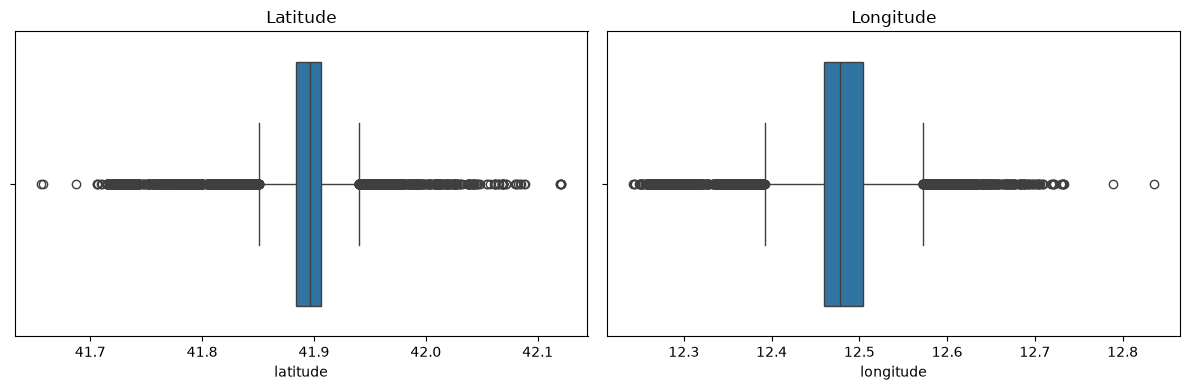

In [69]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

sns.boxplot(x=selected["latitude"], ax=axes[0])
axes[0].set_title("Latitude")

sns.boxplot(x=selected["longitude"], ax=axes[1])
axes[1].set_title("Longitude")

plt.tight_layout()
plt.show()

As we can see the number of observations decrease to 28317 . These means that 5247 were outliers.

In [70]:
def remove_outliers_iqr_mask(series):
    q1 = series.quantile(0.25)
    q3 = series.quantile(0.75)
    iqr = q3 - q1
    lower_bound = q1 - 1.5 * iqr
    upper_bound = q3 + 1.5 * iqr
    return (series >= lower_bound) & (series <= upper_bound)

valid_mask = remove_outliers_iqr_mask(coords["latitude"]) & remove_outliers_iqr_mask(coords["longitude"])
coords = coords.loc[valid_mask].copy()

print(coords.shape)

(30987, 2)


### Standardization of the observations

To account for variations in measurement units and scale, we standardize the data in order to preserve the relationships between features.


In [71]:
# Standardize coordinates before K-Means
scaler = StandardScaler()
coords[["latitude_scaled", "longitude_scaled"]] = scaler.fit_transform(coords[["latitude", "longitude"]])


coords.head()

,latitude,longitude,latitude_scaled,longitude_scaled
0,41.87136,12.48215,-1.576979,-0.048516
2,41.92582,12.46928,1.977063,-0.467205
3,41.90823,12.45293,0.829145,-0.999105
4,41.88992,12.46823,-0.365759,-0.501364
5,41.88992,12.46823,-0.365759,-0.501364


After this steps we are in position to cluster the data. 

First, we need to know the number of clusters we are going to create, so we have to find the optimal number.To do this we are going to use the ELBOW METHOD. The Elbow plot allows us to plot the inertia, which is a measure of how well the data was clustered by the k-means algorithm, against the number of clusters. From this plot, we are looking for a point where the inertia begins to slow.

## ELBOW METHOD

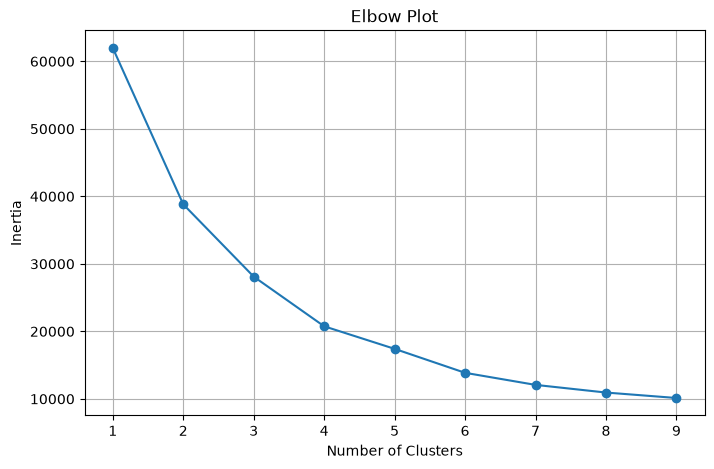

In [72]:
# Create a function to work out the optimum number of clusters
def k_means_plot_elbow(data:pd.DataFrame, max_k:int):
	cluster_sizes = [ ]
	inertias = [ ]

	for k in range(1, max_k):
		kmeans = KMeans(n_clusters=k, random_state=42)
		kmeans.fit(data)

		cluster_sizes.append(k)
		inertias.append(kmeans.inertia_)

	# Generate the elbow plot
	plt.figure(figsize=(8, 5))
	plt.plot(cluster_sizes, inertias, 'o-')
	plt.xlabel('Number of Clusters')
	plt.ylabel('Inertia')
	plt.title('Elbow Plot')
	plt.grid(True)
	plt.show()

k_means_plot_elbow(coords[['latitude_scaled', 'longitude_scaled']], 10)

## Elbow Plot Analysis

The elbow plot shows the inertia (sum of squared distances from each point to its 
cluster centroid) as a function of the number of clusters k.

Ideally, we look for the point where the curve bends sharply (the "elbow") 
indicating that adding more clusters no longer significantly reduces inertia.

In this case, the curve decreases steeply from k=1 to k=4, and then begins to 
flatten out. However, there is no single sharp elbow ,the reduction in inertia 
continues gradually beyond k=4, making it difficult to determine an optimal k 
from this plot alone.

Based on the elbow plot, k=5 appears to be a reasonable choice, as the marginal 
gain in inertia reduction becomes less pronounced after this point. To validate 
this decision, we complement the elbow method with a Silhouette analysis, which 
provides a more rigorous measure of cluster quality.

## SILHOUETTE

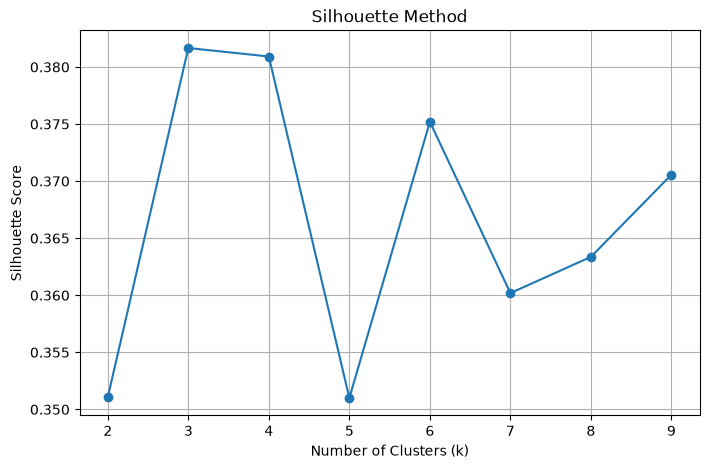

The optimal number of clusters is: 3


In [73]:
from sklearn.metrics import silhouette_score

def k_means_plot_silhouette(data:pd.DataFrame, max_k:int):
    silhouette_scores = []
    k_values = range(2, max_k)  # k must be at least 2

    for k in k_values:
        kmeans = KMeans(n_clusters=k, random_state=42)
        labels = kmeans.fit_predict(data)  # Cluster labels
        score = silhouette_score(data, labels)  # Compute silhouette score
        silhouette_scores.append(score)

    # Plot the silhouette scores
    plt.figure(figsize=(8, 5))
    plt.plot(k_values, silhouette_scores, marker='o')
    plt.title("Silhouette Method")
    plt.xlabel("Number of Clusters (k)")
    plt.ylabel("Silhouette Score")
    plt.grid(True)
    plt.show()

    # Find the best number of clusters
    best_k = k_values[silhouette_scores.index(max(silhouette_scores))]
    print(f"The optimal number of clusters is: {best_k}")

k_means_plot_silhouette(coords[['latitude_scaled', 'longitude_scaled']], 10)

After running the Silhoutte method we confirm that te optimal number of clusters is 5.

For n_clusters = 2 The average silhouette_score is : 0.35194652140718335
For n_clusters = 3 The average silhouette_score is : 0.38077997164756194
For n_clusters = 4 The average silhouette_score is : 0.3811056398524726
For n_clusters = 5 The average silhouette_score is : 0.39417211109963207


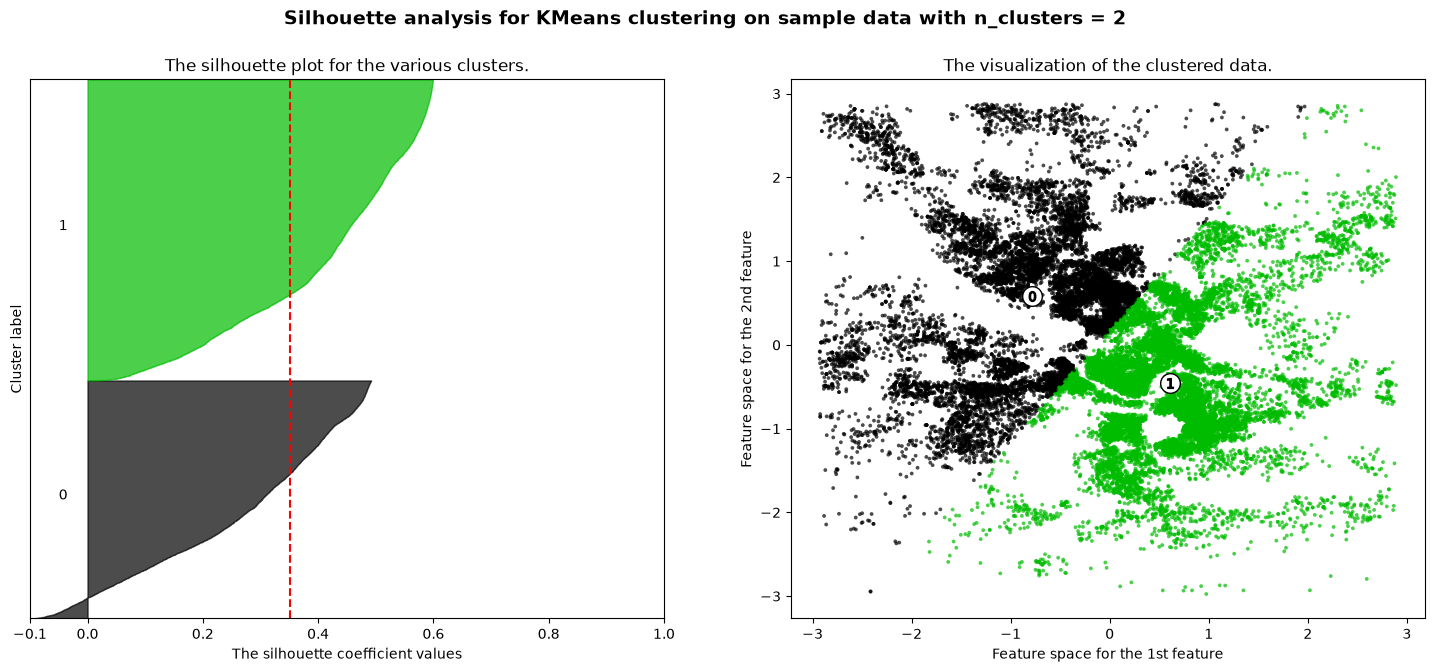

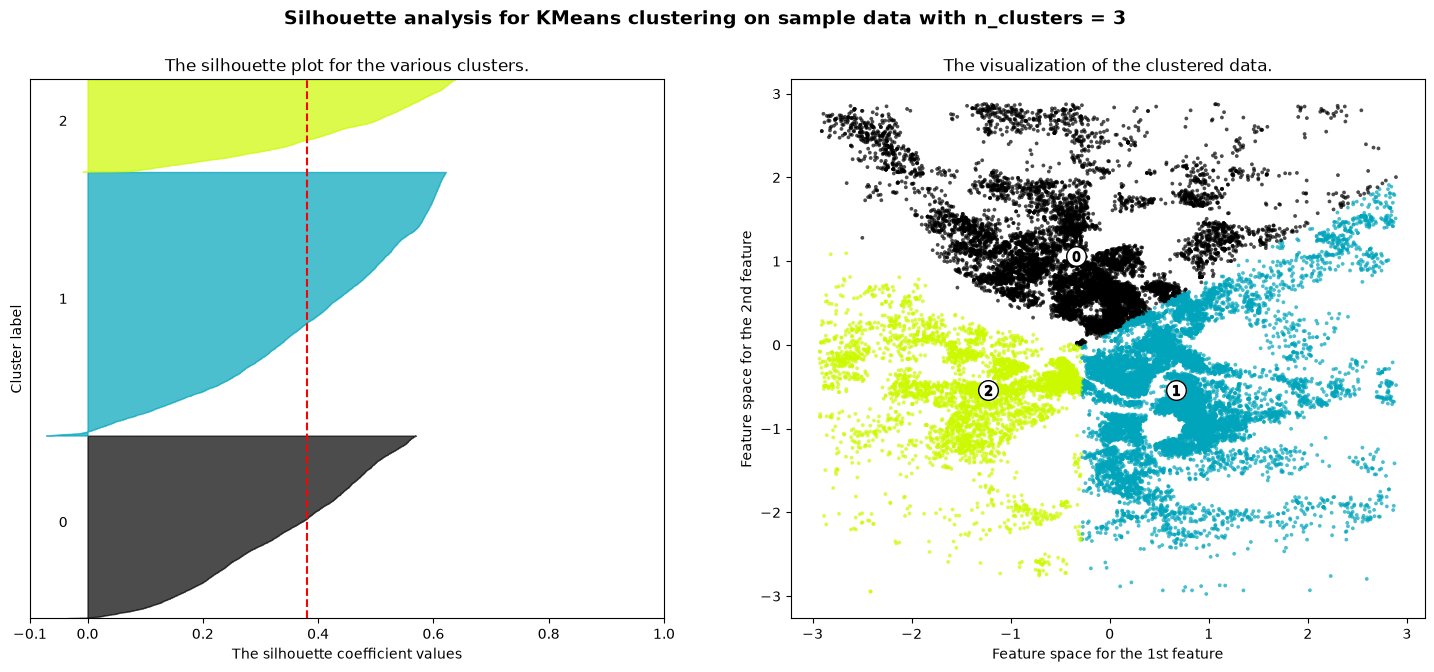

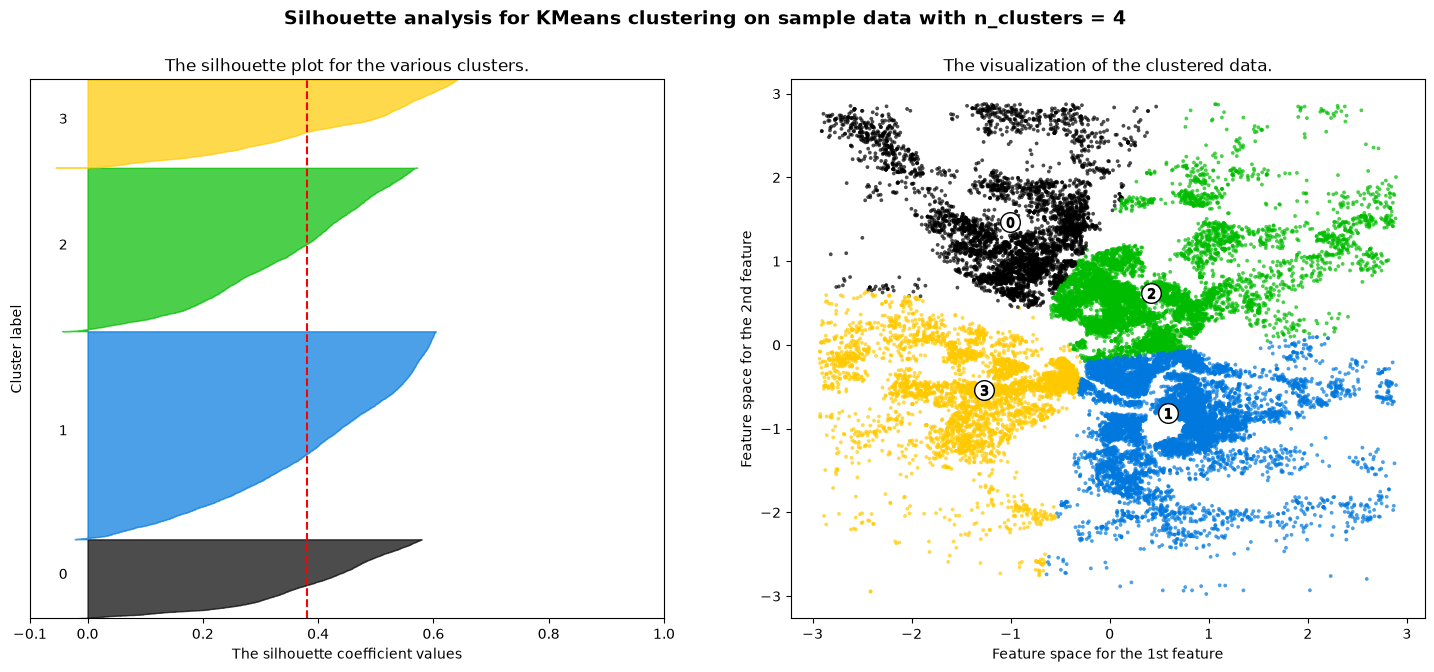

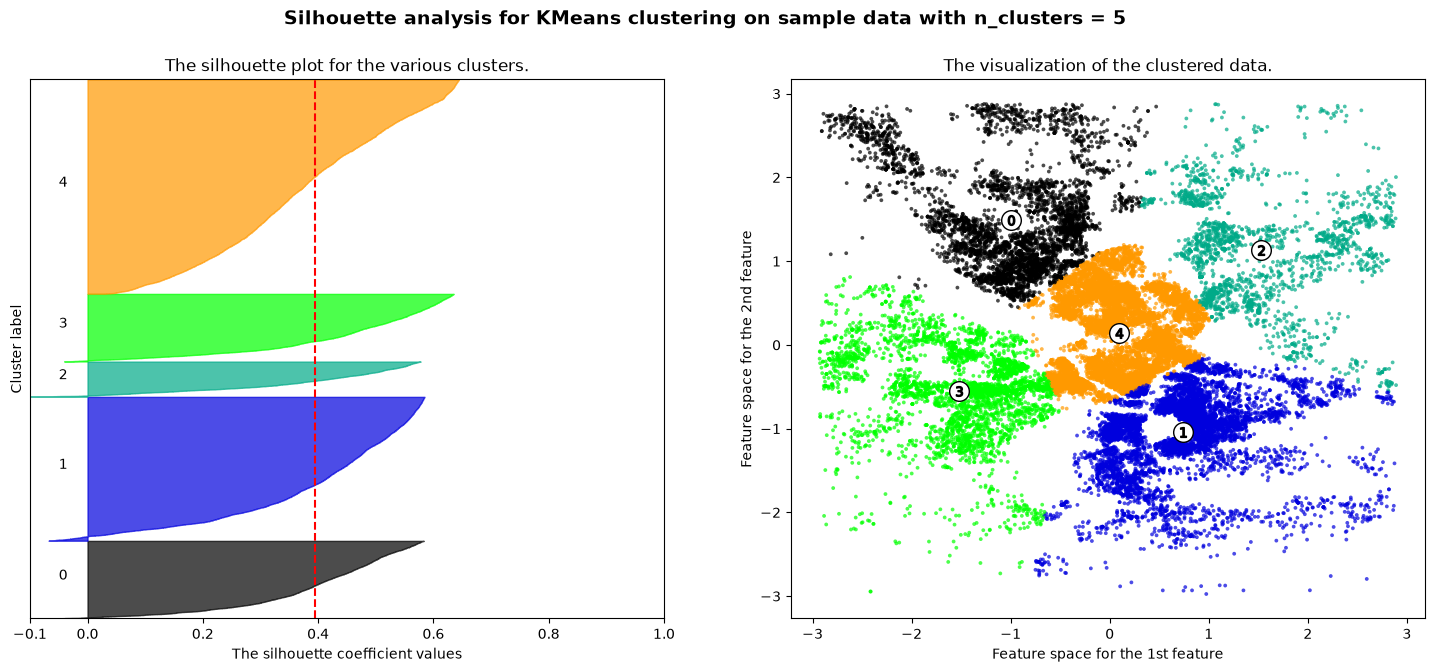

In [74]:
from sklearn.metrics import silhouette_samples
import matplotlib.cm as cm
# adapted from https://scikit-learn.org/stable/auto_examples/cluster/plot_kmeans_silhouette_analysis.html
def silhouette_sklearn(X:np.ndarray, clusters:range):
    for n_clusters in clusters:
        # Create a subplot with 1 row and 2 columns
        fig, (ax1, ax2) = plt.subplots(1, 2)
        fig.set_size_inches(18, 7)

        # The 1st subplot is the silhouette plot
        # The silhouette coefficient can range from -1, 1 but in this example all
        # lie within [-0.1, 1]
        ax1.set_xlim([-0.1, 1])
        # The (n_clusters+1)*10 is for inserting blank space between silhouette
        # plots of individual clusters, to demarcate them clearly.
        ax1.set_ylim([0, len(X) + (n_clusters + 1) * 10])

        # Initialize the clusterer with n_clusters value and a random generator
        # seed of 10 for reproducibility.
        clusterer = KMeans(n_clusters=n_clusters, random_state=10)
        cluster_labels = clusterer.fit_predict(X)

        # The silhouette_score gives the average value for all the samples.
        # This gives a perspective into the density and separation of the formed
        # clusters
        silhouette_avg = silhouette_score(X, cluster_labels)
        print(
            "For n_clusters =",
            n_clusters,
            "The average silhouette_score is :",
            silhouette_avg,
        )

        # Compute the silhouette scores for each sample
        sample_silhouette_values = silhouette_samples(X, cluster_labels)

        y_lower = 10
        for i in range(n_clusters):
            # Aggregate the silhouette scores for samples belonging to
            # cluster i, and sort them
            ith_cluster_silhouette_values = sample_silhouette_values[cluster_labels == i]

            ith_cluster_silhouette_values.sort()

            size_cluster_i = ith_cluster_silhouette_values.shape[0]
            y_upper = y_lower + size_cluster_i

            color = cm.nipy_spectral(float(i) / n_clusters)
            ax1.fill_betweenx(
                np.arange(y_lower, y_upper),
                0,
                ith_cluster_silhouette_values,
                facecolor=color,
                edgecolor=color,
                alpha=0.7,
            )

            # Label the silhouette plots with their cluster numbers at the middle
            ax1.text(-0.05, y_lower + 0.5 * size_cluster_i, str(i))

            # Compute the new y_lower for next plot
            y_lower = y_upper + 10  # 10 for the 0 samples

        ax1.set_title("The silhouette plot for the various clusters.")
        ax1.set_xlabel("The silhouette coefficient values")
        ax1.set_ylabel("Cluster label")

        # The vertical line for average silhouette score of all the values
        ax1.axvline(x=silhouette_avg, color="red", linestyle="--")

        ax1.set_yticks([])  # Clear the yaxis labels / ticks
        ax1.set_xticks([-0.1, 0, 0.2, 0.4, 0.6, 0.8, 1])

        # 2nd Plot showing the actual clusters formed
        colors = cm.nipy_spectral(cluster_labels.astype(float) / n_clusters)
        ax2.scatter(
            X[:, 0], X[:, 1], marker=".", s=30, lw=0, alpha=0.7, c=colors, edgecolor="k"
        )

        # Labeling the clusters
        centers = clusterer.cluster_centers_
        # Draw white circles at cluster centers
        ax2.scatter(
            centers[:, 0],
            centers[:, 1],
            marker="o",
            c="white",
            alpha=1,
            s=200,
            edgecolor="k",
        )

        for i, c in enumerate(centers):
            ax2.scatter(c[0], c[1], marker="$%d$" % i, alpha=1, s=50, edgecolor="k")

        ax2.set_title("The visualization of the clustered data.")
        ax2.set_xlabel("Feature space for the 1st feature")
        ax2.set_ylabel("Feature space for the 2nd feature")

        plt.suptitle(
            "Silhouette analysis for KMeans clustering on sample data with n_clusters = %d"
            % n_clusters,
            fontsize=14,
            fontweight="bold",
        )

    plt.show()

silhouette_sklearn(coords[['latitude_scaled', 'longitude_scaled']].values, range(2, 6))

Now the application of the k-means is made, using 5 clusters. The output of the function k-means is the number of the cluster where the observation belongs to. After this step we are going to merge the column `location_cluster` with the main dataframe `selected`.

In [75]:
# K-Means
kmeans = KMeans(n_clusters=5, random_state=42, n_init=10)
coords["location_cluster"] = kmeans.fit_predict(coords[["latitude_scaled", "longitude_scaled"]])

# Merge back into selected using index
selected = selected.merge(
    coords[["location_cluster"]],
    left_index=True,
    right_index=True,
    how="left"
)

print("Listings with cluster assigned:", coords.shape[0])
print("Listings without cluster (outliers):", selected["location_cluster"].isnull().sum())
selected.head()

Listings with cluster assigned: 30987
Listings without cluster (outliers): 3337


,price,latitude,longitude,property_type,room_type,accommodates,bedrooms,beds,bathrooms,host_is_superhost,...,neighbourhood_cleansed_VII San Giovanni/Cinecittà,neighbourhood_cleansed_VIII Appia Antica,neighbourhood_cleansed_X Ostia/Acilia,neighbourhood_cleansed_XI Arvalia/Portuense,neighbourhood_cleansed_XII Monte Verde,neighbourhood_cleansed_XIII Aurelia,neighbourhood_cleansed_XIV Monte Mario,neighbourhood_cleansed_XV Cassia/Flaminia,distance_to_colosseum,location_cluster
0,59.52,41.87136,12.48215,Private room,Private room,1,1.0,1.0,1.5,0,...,False,True,False,False,False,False,False,False,2.252726,2.0
2,117.13,41.92582,12.46928,Entire rental unit,Entire home/apt,3,2.0,3.0,1.0,1,...,False,False,False,False,False,False,False,False,4.389669,0.0
3,160.60,41.90823,12.45293,Entire condo,Entire home/apt,5,2.0,3.0,1.0,0,...,False,False,False,False,False,False,False,False,3.824847,0.0
4,243.67,41.88992,12.46823,Entire vacation home,Entire home/apt,4,1.0,3.0,1.0,1,...,False,False,False,False,False,False,False,False,1.989591,3.0
5,302.50,41.88992,12.46823,Entire vacation home,Entire home/apt,4,2.0,4.0,1.0,1,...,False,False,False,False,False,False,False,False,1.989591,3.0


## DBSCAN

Now we are going to use DBSCAN to cluster the data. For this model we need to define the parameter of Epsilon (ε) wich  is the maximum radius DBSCAN uses to search for neighboring data points. If point B is within distance ε of point A, they are considered neighbors. Setting ε too small leaves valid clusters fragmented as noise; setting it too large merges distinct clusters together.

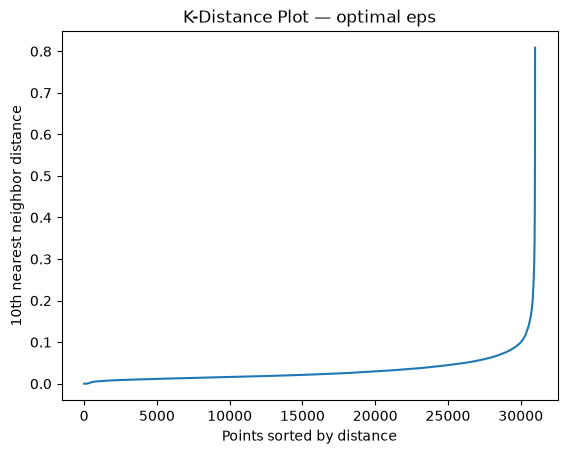

In [76]:
from sklearn.neighbors import NearestNeighbors

neighbors = NearestNeighbors(n_neighbors=10)
neighbors.fit(coords[["latitude_scaled", "longitude_scaled"]])
distances, _ = neighbors.kneighbors(coords[["latitude_scaled", "longitude_scaled"]])

distances = np.sort(distances[:, -1])
plt.plot(distances)
plt.xlabel("Points sorted by distance")
plt.ylabel("10th nearest neighbor distance")
plt.title("K-Distance Plot — optimal eps")
plt.show()

Approximately observing the plot, the Epsilon (ε) value is 0.1.

In [77]:
# DBSCAN with density-based clustering
sc = DBSCAN(eps=0.1, min_samples=10)
coords["dbscan_cluster"] = sc.fit_predict(coords[["latitude_scaled", "longitude_scaled"]])

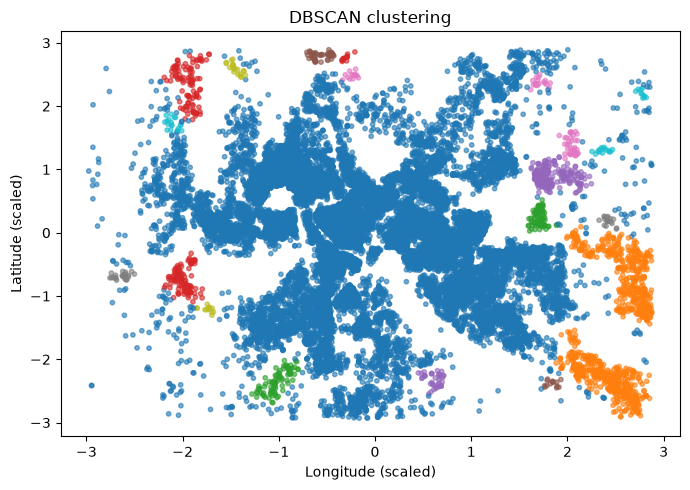

In [78]:
fig, ax = plt.subplots(figsize=(7, 5))

scatter = ax.scatter(coords["longitude_scaled"], coords["latitude_scaled"], c=coords["dbscan_cluster"], cmap="tab10", s=10, alpha=0.6)
ax.set_title("DBSCAN clustering")
ax.set_xlabel("Longitude (scaled)")
ax.set_ylabel("Latitude (scaled)")

plt.tight_layout()
plt.show()


The DBSCAN clustering plot reveals an important characteristic of the Rome Airbnb 
dataset: the vast majority of listings form a single large dense cluster (shown in 
blue), which corresponds to the central and most active areas of Rome where Airbnb 
listings are heavily concentrated. 

The smaller clusters scattered around the edges represent distinct neighborhoods 
or suburban areas that are geographically separated from the main urban core, 
with sufficient local density to form their own clusters.

For this reason, **K-Means with k=5 is preferred for the modeling phase**, as it 
forces a more balanced geographic segmentation of the city and assigns every 
listing to a cluster without producing noise points. DBSCAN remains valuable as 
an exploratory tool to confirm the geographic density structure of the dataset.